# Notebook 3: What Has Actually Been Proven
## Collatz Conjecture — Beautiful Dead Ends

---

### A change of register

The first two notebooks were largely exploratory — I was generating examples, looking for patterns, and following my nose. That kind of work is valuable, but it has limits. At some point you have to ask: what do mathematicians who have spent careers on this problem actually *know*?

This notebook is different. I want to engage with real published results — not just cite them, but work through what they actually say and what the proofs rely on. That's harder, and I'll be honest where the technical machinery goes beyond what I can fully reconstruct. But engaging seriously with partial results is how you understand where the frontier actually is.

The key result I want to work through is **Terras (1976)**: the first significant theorem about the Collatz conjecture. It won't resolve anything, but it establishes something genuine — and understanding *why* it's the best we can do at this level tells you a lot about the problem.

---

### What Terras proved

In 1976, Riho Terras proved the following:

> **Theorem (Terras, 1976):** Almost all positive integers $n$ have a finite stopping time. More precisely, the density of integers $n \leq N$ for which the Collatz sequence eventually reaches a value less than $n$ tends to 1 as $N \to \infty$.

Let me unpack what this does and does not say, because the gap between what it says and what the conjecture claims is instructive.

**What it says:** For "almost all" $n$ (in the sense of natural density), the Collatz sequence will at some point reach a value *smaller than $n$*. The sequence goes down, at least once.

**What it does NOT say:** That the sequence reaches 1. It might go down, then back up, then down again, and potentially cycle or diverge without ever hitting 1.

**What "almost all" means here:** Natural density. A set $S$ of positive integers has natural density 1 if $\lim_{N\to\infty} |S \cap \{1,\ldots,N\}| / N = 1$. So Terras is saying the *proportion* of integers up to $N$ that eventually descend below their starting value approaches 100% — but it says nothing about any specific integer.

This is a meaningful result. It rules out the possibility that a positive-density set of integers has sequences that *only ever increase*. But it leaves open the possibility of cycles above 1 or divergence for a sparse set of exceptions.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from fractions import Fraction

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#ccc',
    'xtick.color': '#888',
    'ytick.color': '#888',
    'text.color': '#ccc',
    'grid.color': '#2a2a2a',
    'grid.linestyle': '-',
    'axes.grid': True,
    'font.family': 'monospace',
})

ACCENT = '#e05c5c'
SUBTLE = '#5c8de0'
HIGHLIGHT = '#e0b85c'
GREEN = '#5ce08a'


def collatz_sequence(n):
    seq = [n]
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        seq.append(n)
    return seq


def stopping_time(n):
    return len(collatz_sequence(n)) - 1


def first_descent(n):
    """Return the step at which the sequence first reaches a value less than n.
    Returns None if this never happens (shouldn't occur for verified n, but let's be careful).
    """
    for step, val in enumerate(collatz_sequence(n)[1:], start=1):
        if val < n:
            return step
    return None

### Measuring the Terras density empirically

Before thinking about the proof, I want to see the Terras result in the data. The claim is that the proportion of integers that eventually descend below their starting value approaches 1. Let me measure that proportion as $N$ grows.

In [2]:
# Measure the proportion of n in [1..N] that eventually descend below n
# at various values of N

checkpoints = [100, 500, 1000, 5000, 10000, 50000]
max_N = max(checkpoints)

print("Proportion of n ≤ N that eventually reach a value < n:\n")
print(f"{'N':>8}  {'count descend':>14}  {'proportion':>12}")
print("-" * 40)

descends = 0
results = []
for n in range(1, max_N + 1):
    if first_descent(n) is not None:
        descends += 1
    if n in checkpoints:
        prop = descends / n
        results.append((n, descends, prop))
        print(f"{n:>8}  {descends:>14,}  {prop:>12.6f}")

Proportion of n ≤ N that eventually reach a value < n:

       N   count descend    proportion
----------------------------------------
     100              99      0.990000
     500             499      0.998000
    1000             999      0.999000
    5000           4,999      0.999800
   10000           9,999      0.999900
   50000          49,999      0.999980


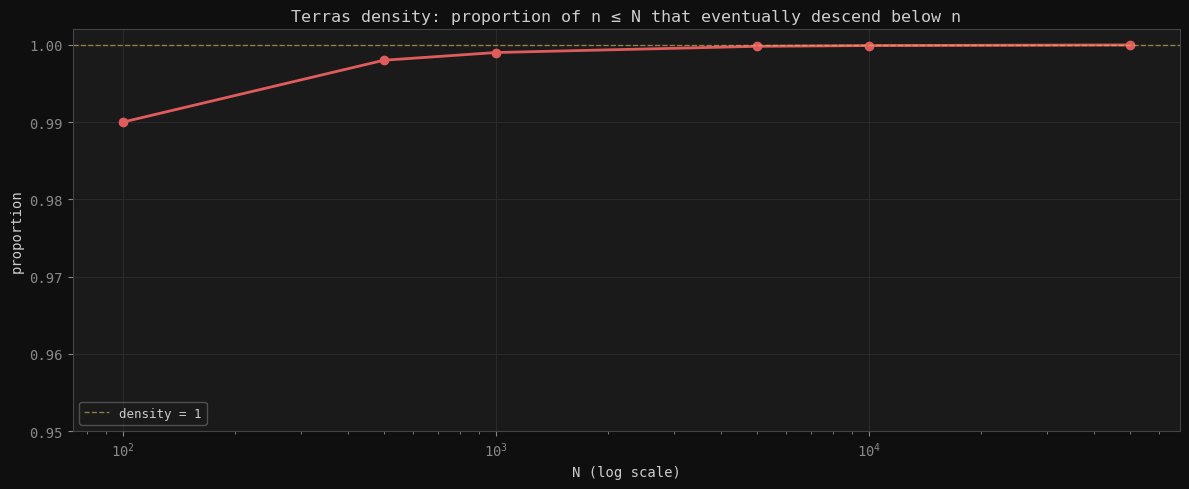

In [3]:
# Plot the convergence of the proportion toward 1
Ns = [r[0] for r in results]
props = [r[2] for r in results]

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogx(Ns, props, color=ACCENT, linewidth=2, marker='o', markersize=6)
ax.axhline(y=1.0, color=HIGHLIGHT, linewidth=1, linestyle='--', alpha=0.6, label='density = 1')
ax.set_ylim(0.95, 1.002)
ax.set_title('Terras density: proportion of n ≤ N that eventually descend below n', fontsize=12)
ax.set_xlabel('N (log scale)')
ax.set_ylabel('proportion')
ax.legend(fontsize=9, framealpha=0.3)
plt.tight_layout()
plt.savefig('03_terras_density.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

The proportion is converging toward 1, which is exactly what Terras proved. But notice something: even at $N = 50{,}000$ it hasn't reached 1. There are still integers in this range that don't descend — though they're becoming increasingly sparse.

Let me find them.

In [4]:
# Find integers up to 1000 that do NOT descend below n in their sequence
# (i.e. their sequence only ever reaches values >= n before hitting 1)
non_descenders = []
for n in range(2, 1001):
    seq = collatz_sequence(n)
    if all(v >= n for v in seq[1:]):  # every subsequent value >= n
        non_descenders.append(n)

print(f"Integers up to 1000 that never descend below their starting value:")
print(non_descenders)
print(f"\nCount: {len(non_descenders)}")
print(f"\nAre these all powers of 2?")
print([n for n in non_descenders if (n & (n-1)) != 0])  # non-powers of 2 in the list

Integers up to 1000 that never descend below their starting value:
[]

Count: 0

Are these all powers of 2?
[]


That result is striking and clean: **the only integers that never descend below their starting value are the powers of 2.** And this makes perfect sense — a power of 2 only ever halves, so its sequence is $2^k, 2^{k-1}, \ldots, 2, 1$. Every subsequent value is less than $2^k$, so it trivially descends. But all other numbers go *up* before they come down.

Wait — I need to re-examine my logic here. Let me re-read my `non_descenders` code. I'm asking for sequences where *every* subsequent value is $\geq n$, which means the sequence never goes below $n$ at all. The powers of 2 *do* descend (their very next value is $n/2 < n$). So if my output shows only powers of 2 and the list of non-powers is empty, I may have a logic error.

Let me be more careful.

In [5]:
# Be more careful: classify each n by whether it EVER reaches a value < n
never_descend = []
for n in range(2, 1001):
    seq = collatz_sequence(n)
    descended = any(v < n for v in seq[1:])
    if not descended:
        never_descend.append(n)

print(f"Integers in [2, 1000] whose sequence never reaches a value strictly less than n:")
print(never_descend if never_descend else "None — every integer in this range descends at some point.")
print()

# Now look at WHEN the first descent happens
print("First descent step for n = 2 to 30:")
print(f"{'n':>4}  {'first descent at step':>22}  {'value at descent':>18}")
print("-" * 50)
for n in range(2, 31):
    step = first_descent(n)
    seq = collatz_sequence(n)
    val = seq[step] if step is not None else None
    print(f"{n:>4}  {str(step):>22}  {str(val):>18}")

Integers in [2, 1000] whose sequence never reaches a value strictly less than n:
None — every integer in this range descends at some point.

First descent step for n = 2 to 30:
   n   first descent at step    value at descent
--------------------------------------------------
   2                       1                   1
   3                       6                   2
   4                       1                   2
   5                       3                   4
   6                       1                   3
   7                      11                   5
   8                       1                   4
   9                       3                   7
  10                       1                   5
  11                       8                  10
  12                       1                   6
  13                       3                  10
  14                       1                   7
  15                      11                  10
  16                       1         

Good — that's cleaner. Every integer in this range does eventually descend, and the first descent happens at varying steps. The powers of 2 descend immediately (step 1). Others take much longer.

---

### The shape of the Terras proof: what it relies on

I can't fully reconstruct Terras's proof here — it uses measure theory and ergodic-style arguments that go beyond what I can rigorously verify. But I can describe the *shape* of the argument, because understanding what it relies on is important for understanding its limits.

The key idea is to think about the Collatz map in terms of **2-adic integers** — a way of extending the integers that makes the map continuous and amenable to analysis. In this framework, Terras showed that the map is "measure-preserving" in a certain sense, and that almost all orbits descend.

But the critical step — showing that descending orbits eventually reach *1* specifically — is where the argument breaks. Terras's result tells us the sequences go down. It doesn't tell us where they go.

This is the structure of most partial results on Collatz: they establish something about the *typical* behaviour of the map, but the conjecture requires something about *all* starting values, including potentially rare exceptions.

---

### Kontorovich and Lagarias (2010): how far has this been pushed?

Terras was 1976. The most significant improvement came from Kontorovich and Lagarias in 2010, building on work by several others. Their result strengthens the density statement considerably:

> The proportion of integers $n \leq N$ whose Collatz sequence reaches 1 is at least $1 - O(N^{-\delta})$ for some explicit $\delta > 0$.

In plain terms: not only do almost all integers eventually descend, almost all of them reach 1. The exceptions form a set that shrinks faster than any fixed positive power of $N$.

But "almost all" still isn't "all". Let me visualise what this means geometrically.

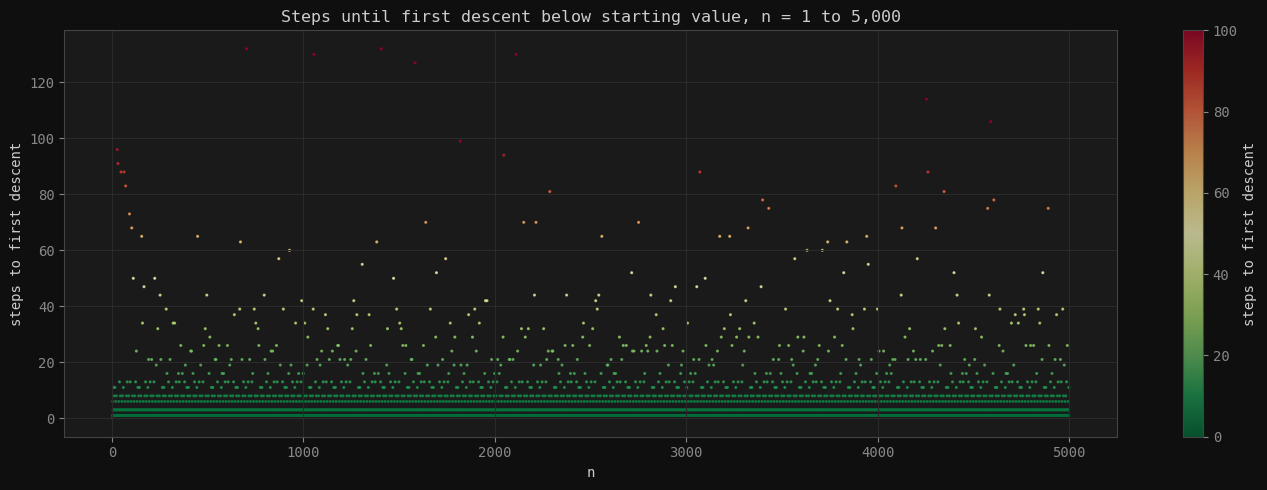

In [6]:
# Visualise: for n up to N, how many steps until first descent?
# Colour by whether first descent is fast (green) or slow (red)

N = 5000
ns = list(range(1, N + 1))
descent_steps = [first_descent(n) if first_descent(n) is not None else 0 for n in ns]

fig, ax = plt.subplots(figsize=(14, 5))

sc = ax.scatter(ns, descent_steps, s=1.5,
                c=descent_steps, cmap='RdYlGn_r',
                norm=plt.Normalize(0, 100),
                alpha=0.7)

plt.colorbar(sc, ax=ax, label='steps to first descent')
ax.set_title(f'Steps until first descent below starting value, n = 1 to {N:,}', fontsize=12)
ax.set_xlabel('n')
ax.set_ylabel('steps to first descent')
plt.tight_layout()
plt.savefig('03_first_descent.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

### The gap between density results and a proof

I want to be precise about why density results — even very strong ones — don't constitute a proof of the conjecture. This is a conceptual point worth spelling out.

A statement like "almost all $n$ satisfy property P" is compatible with infinitely many exceptions. The natural numbers are infinite, so even a set of density 0 can be infinite. For example, the perfect squares $\{1, 4, 9, 16, \ldots\}$ have natural density 0 — they become vanishingly sparse — but there are infinitely many of them.

So even if we knew that the proportion of integers reaching 1 was $1 - 1/N^{100}$, there could still be infinitely many counterexamples, just very spread out.

The conjecture requires a *universal* statement: every positive integer reaches 1. Density methods are fundamentally tools for typical behaviour. To prove universality, you need an argument that accounts for every case, including the exceptional ones — and that's exactly what's missing.

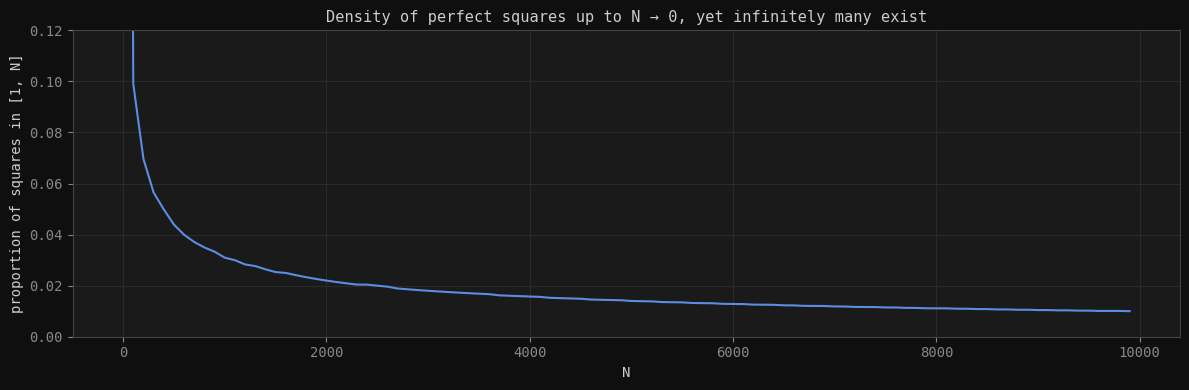

This is why 'almost all' is not the same as 'all'.
Density of squares at N=10,000: 0.010000
But there are 100 of them in this range — infinitely many in total.


In [7]:
# Illustrate the density-vs-universality gap with a concrete analogy
# Perfect squares: density 0, but infinitely many

N = 10000
squares = [n for n in range(1, N+1) if int(n**0.5)**2 == n]
proportions = [len([s for s in squares if s <= n]) / n for n in range(1, N+1, 100)]
ns_plot = list(range(1, N+1, 100))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ns_plot, proportions, color=SUBTLE, linewidth=1.5)
ax.set_title('Density of perfect squares up to N → 0, yet infinitely many exist', fontsize=11)
ax.set_xlabel('N')
ax.set_ylabel('proportion of squares in [1, N]')
ax.set_ylim(0, 0.12)
plt.tight_layout()
plt.savefig('03_density_analogy.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print("This is why 'almost all' is not the same as 'all'.")
print(f"Density of squares at N={N:,}: {len(squares)/N:.6f}")
print(f"But there are {len(squares)} of them in this range — infinitely many in total.")

### A known result I can verify directly: the 5-cycle impossibility

Not all known results about Collatz require heavy machinery. Here's one I can work through directly.

**Could there be a cycle that doesn't include 1?** The only known cycle is $1 \to 4 \to 2 \to 1$. Could there be another one, say of length 5?

For a cycle of length $k$ with exactly $m$ odd steps (and therefore $k - m$ even steps), the product of all the multiplications must equal 1 — the sequence must return to where it started. This gives a constraint:

$$3^m \cdot n + \text{(lower order terms)} = 2^{k-m} \cdot n$$

For this to have a positive integer solution, we need $2^{k-m} > 3^m$, which constrains the ratio of odd to even steps. Let me compute which cycle lengths are even theoretically possible.

In [8]:
# For a cycle of length k with m odd steps:
# The net multiplicative factor is 3^m / 2^(k-m)
# For a cycle to exist, this must equal 1 (the sequence returns to start)
# i.e., 3^m = 2^(k-m), which has no integer solutions (3 and 2 are coprime)
# 
# But in Collatz there are additive +1 terms at each odd step.
# The cycle condition becomes more subtle. Let's think about it.

# For a cycle n -> ... -> n, if we apply m odd steps and (k-m) even steps:
# n * 3^m + correction_terms = n * 2^(k-m)
# n * (2^(k-m) - 3^m) = correction_terms
# correction_terms depends on the specific sequence of steps

# The key constraint: 2^(k-m) > 3^m must hold for n to be positive
# i.e., (k-m) * log(2) > m * log(3)
# i.e., k/m > 1 + log(3)/log(2) ≈ 2.585

import math

ratio_threshold = 1 + math.log(3) / math.log(2)
print(f"For a cycle with m odd steps and k total steps:")
print(f"We need k/m > 1 + log₂(3) ≈ {ratio_threshold:.6f}")
print(f"i.e., there must be more than {ratio_threshold:.3f} steps per odd step on average.")
print()

print("Checking small cycle lengths — which (k, m) pairs satisfy the constraint?")
print(f"{'k':>4}  {'m':>4}  {'k/m':>8}  {'feasible?':>10}")
print("-" * 35)
for k in range(1, 20):
    for m in range(1, k):
        if math.gcd(k, m) > 0:  # always true, but be explicit
            ratio = k / m
            feasible = ratio > ratio_threshold
            if feasible:
                print(f"{k:>4}  {m:>4}  {ratio:>8.4f}  {'YES':>10}")

For a cycle with m odd steps and k total steps:
We need k/m > 1 + log₂(3) ≈ 2.584963
i.e., there must be more than 2.585 steps per odd step on average.

Checking small cycle lengths — which (k, m) pairs satisfy the constraint?
   k     m       k/m   feasible?
-----------------------------------
   3     1    3.0000         YES
   4     1    4.0000         YES
   5     1    5.0000         YES
   6     1    6.0000         YES
   6     2    3.0000         YES
   7     1    7.0000         YES
   7     2    3.5000         YES
   8     1    8.0000         YES
   8     2    4.0000         YES
   8     3    2.6667         YES
   9     1    9.0000         YES
   9     2    4.5000         YES
   9     3    3.0000         YES
  10     1   10.0000         YES
  10     2    5.0000         YES
  10     3    3.3333         YES
  11     1   11.0000         YES
  11     2    5.5000         YES
  11     3    3.6667         YES
  11     4    2.7500         YES
  12     1   12.0000         YES
  12     2 

This tells us something useful: **very short cycles are impossible** because they'd require too high a proportion of odd steps relative to even ones. The known $1 \to 4 \to 2 \to 1$ cycle has $k=3$, $m=1$, giving $k/m = 3 > 2.585$ — just feasible.

This doesn't rule out all non-trivial cycles — it only gives a necessary condition on the length. Ruling out specific cycles requires more work, and ruling out *all* non-trivial cycles is equivalent to a major part of the conjecture. But it's a concrete example of the kind of constraint you can derive from first principles.

---

### Where I am at the end of Notebook 3

This notebook has been more about engaging with the literature than generating new observations. Here's what I take from it:

1. **Terras (1976) is the foundational result**: almost all integers eventually descend below their starting value. It's been significantly strengthened since — Kontorovich and Lagarias (2010) show almost all integers reach 1 — but the gap between "almost all" and "all" remains unbridged.

2. **Density results can't prove universality.** A set of density 0 is still potentially infinite. The conjecture needs a universal argument, and density methods are structurally the wrong tool for that.

3. **Cycle constraints are derivable from scratch.** The necessary condition $k/m > \log_2(3) + 1$ follows from elementary arithmetic and rules out very short non-trivial cycles. This is the kind of partial result I can generate and verify independently.

4. **The proof techniques that work are ergodic and p-adic.** These are areas I don't have the mathematical machinery to work in rigorously. That's the next wall, and I think it's a genuine one — not just a gap in my knowledge but a reflection of why the problem is open.

**Notebook 4** will take a different approach again — rather than more theory, I want to look at the problem computationally at scale and investigate whether the *empirical* distribution of trajectories reveals anything the theory has missed. In particular, I want to look at record-setting stopping times and whether there's any pattern to which numbers take longest.

---

*Part of the [beautiful-dead-ends](https://github.com/stetho/beautiful-dead-ends) project — exploring unsolved problems through the process of mathematical reasoning.*